In [31]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


with open('data-20250214T173655Z-001/data/train-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    print(data.shape)
    Xtraindata = np.transpose(data.reshape((size, nrows*ncols)))

with open('data-20250214T173655Z-001/data/train-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytrainlabels = data.reshape((size,)) # (Optional)

with open('data-20250214T173655Z-001/data/t10k-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    Xtestdata = np.transpose(data.reshape((size, nrows*ncols)))

with open('data-20250214T173655Z-001/data/t10k-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    ytestlabels = data.reshape((size,)) # (Optional)
        

    
traindata_imgs =  np.transpose(Xtraindata).reshape((60000,28,28))    
print(Xtraindata.shape)
print(ytrainlabels.shape)
print(Xtestdata.shape)
print(ytestlabels.shape)

(47040000,)
(784, 60000)
(60000,)
(784, 10000)
(10000,)


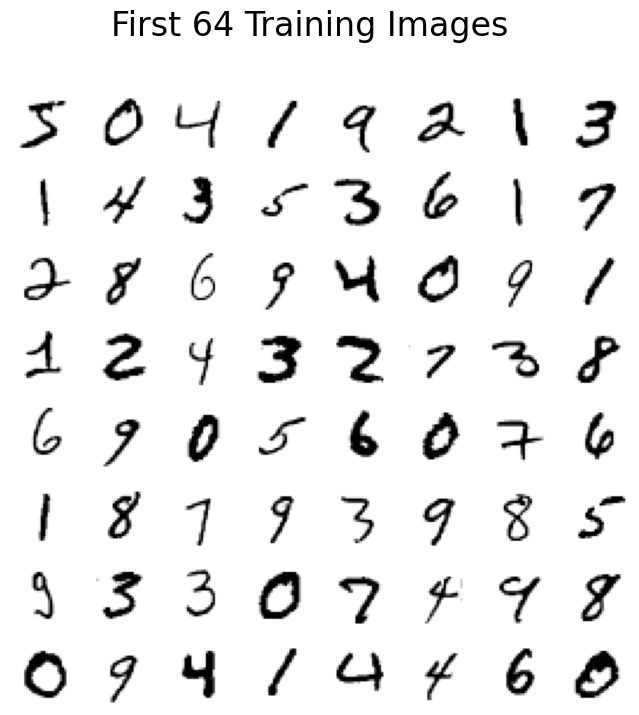

In [32]:
def plot_digits(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
    
    for i in range(N):
        for j in range(N):
            ax[i,j].imshow(XX[:,(N)*i+j].reshape((28, 28)), cmap="Greys")
            ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_digits(Xtraindata, 8, "First 64 Training Images" )

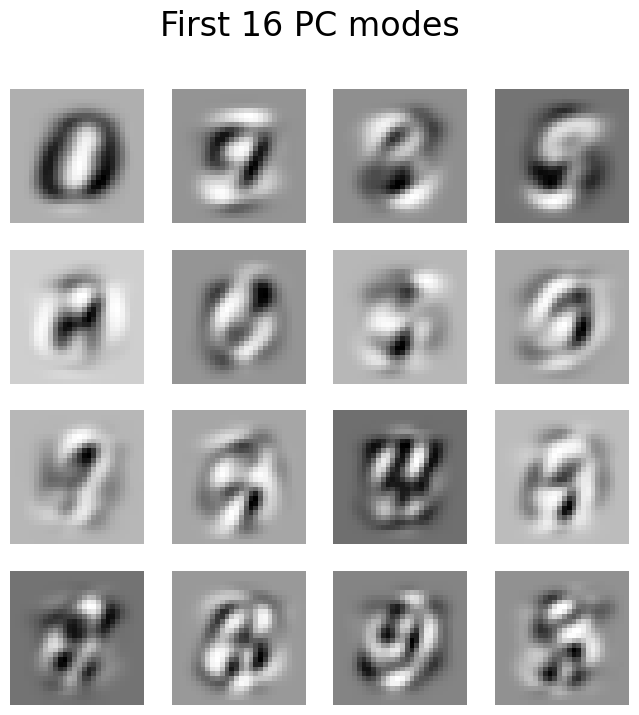

In [33]:
n_components=16
pca = PCA()
pca.fit(Xtraindata.T)  

pc_modes = pca.components_.T

plot_digits(pc_modes, N=4, title="First 16 PC modes")

59 PCA spatial modes are needed to keep to approximate Xtrain up to 85%


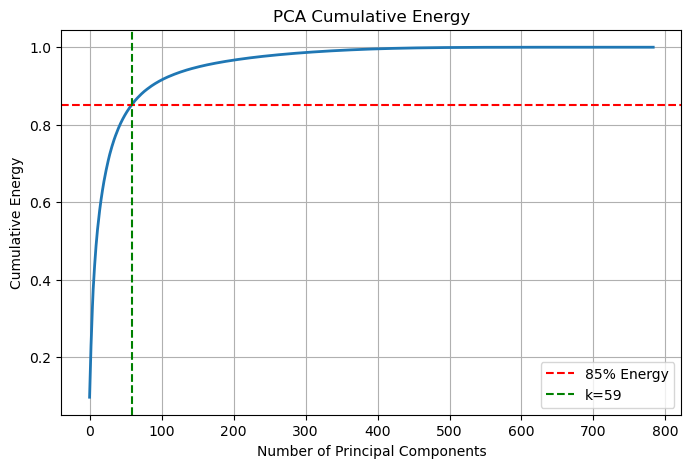

In [34]:
cumulative_energy = np.cumsum(pca.explained_variance_ratio_)
k_85 = np.argmax(cumulative_energy >= 0.85) + 1
print(f"{k_85} PCA spatial modes are needed to keep to approximate Xtrain up to 85%")

# 绘制能量曲线
plt.figure(figsize=(8, 5))
plt.plot(cumulative_energy, linewidth=2)
plt.axhline(y=0.85, color='r', linestyle='--', label="85% Energy")
plt.axvline(x=k_85, color='g', linestyle='--', label=f"k={k_85}")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Energy")
plt.title("PCA Cumulative Energy")
plt.legend()
plt.grid(True)
plt.show()

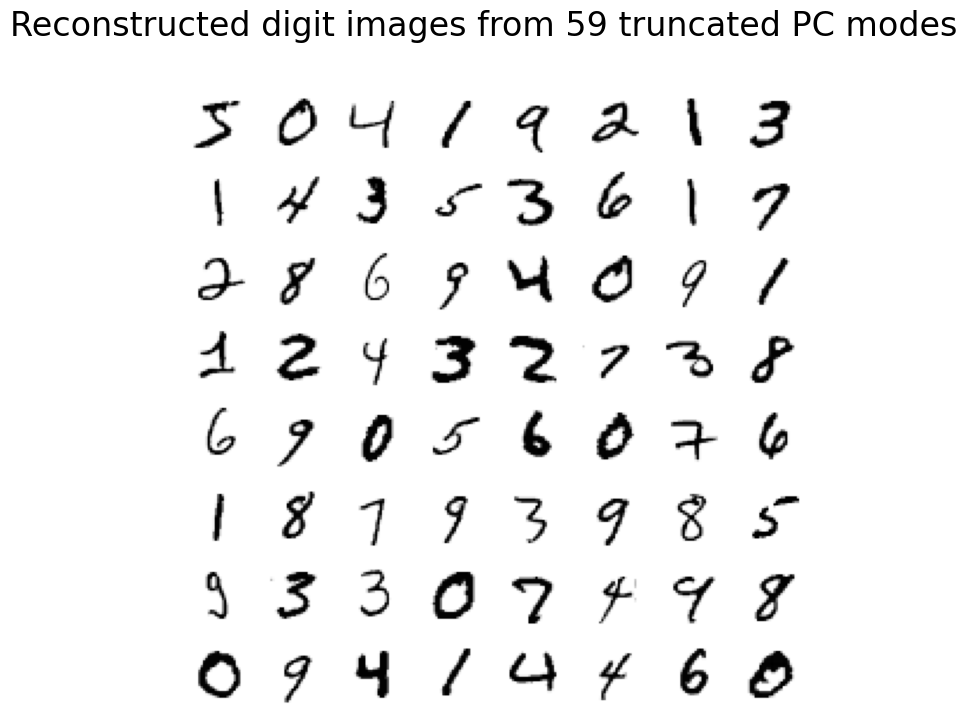

In [35]:
n_components=59
pca_k = PCA()
X_train_pca = pca_k.fit_transform(Xtraindata.T) 
X_inv = pca_k.inverse_transform(X_train_pca)

plot_digits(X_inv.T, N=8, title="Reconstructed digit images from 59 truncated PC modes")

In [36]:
def extract_digits(X, y, digits):
    mask = np.isin(y, digits)
    return X[:, mask], y[mask]

digits = [1, 8]
X_subtrain, y_subtrain = extract_digits(Xtraindata, ytrainlabels, digits)
X_subtest, y_subtest = extract_digits(Xtestdata, ytestlabels, digits)
print(X_subtrain.shape)
print(y_subtrain.shape)
print(X_subtest.shape)
print(y_subtest.shape)

(784, 12593)
(12593,)
(784, 2109)
(2109,)


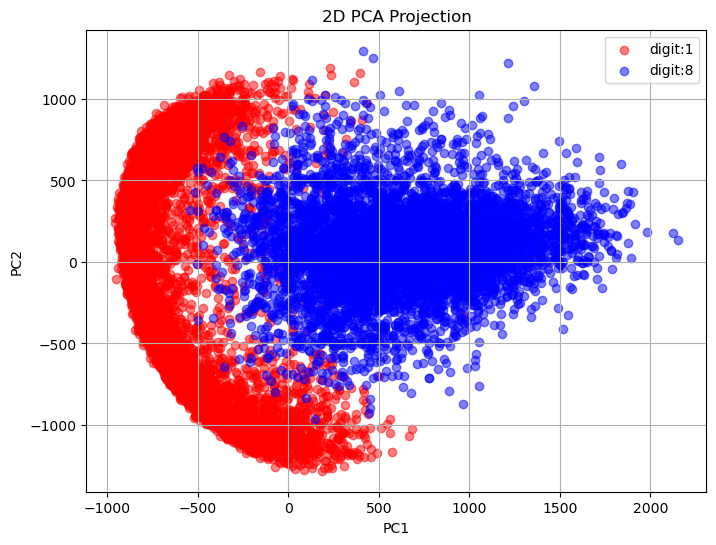

In [37]:
pca = PCA(n_components=2)
X_train18_pca = pca_k.fit_transform(X_subtrain.T) 
mask1 = np.isin(y_subtrain , 1)
mask8 = np.isin(y_subtrain , 8)
plt.figure(figsize=(8, 6))
plt.scatter(X_train18_pca.T[0,mask1], 
            X_train18_pca.T[1,mask1], 
             c='r', label='digit:1', alpha=0.5)
plt.scatter(X_train18_pca.T[0,mask8], 
            X_train18_pca.T[1,mask8], 
             c='b', label='digit:8', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.legend()
plt.grid()
plt.show()

In [38]:
from sklearn.linear_model import RidgeClassifier

pca_k = PCA(n_components=k_85)
X_subtrain_pca = pca_k.fit_transform(X_subtrain.T) 
X_subtest_pca = pca_k.transform(X_subtest.T)

ridge_clf = RidgeClassifier()
ridge_clf.fit(X_subtrain_pca, y_subtrain)

from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(ridge_clf, X_subtrain_pca, y_subtrain, cv=5)
print(f"The accuracy of cross-validation(1 and 8): {cv_scores.mean():.4f}")

y_pred = ridge_clf.predict(X_subtest_pca)
test_accuracy = accuracy_score(y_subtest, y_pred)
print(f"The accuracy for testing(1 and 8): {test_accuracy:.4f}")

The accuracy of cross-validation(1 and 8): 0.9632
The accuracy for testing(1 and 8): 0.9796


In [39]:
digits_38 = [3, 8]
X_subtrain38, y_subtrain38 = extract_digits(Xtraindata, ytrainlabels, digits_38)
X_subtest38, y_subtest38 = extract_digits(Xtestdata, ytestlabels, digits_38)
print(X_subtrain38.shape)
print(y_subtrain38.shape)
print(X_subtest38.shape)
print(y_subtest38.shape)

(784, 11982)
(11982,)
(784, 1984)
(1984,)


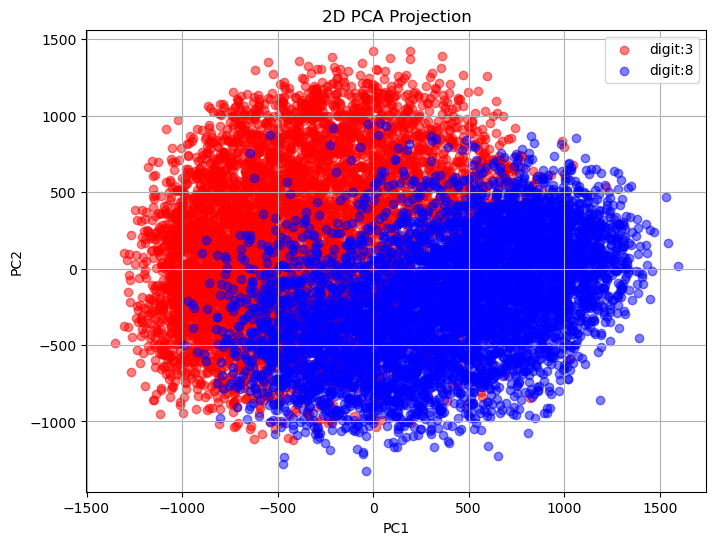

In [40]:
pca = PCA(n_components=2)
X_train38_pca = pca_k.fit_transform(X_subtrain38.T) 
mask3 = np.isin(y_subtrain38 , 3)
mask8 = np.isin(y_subtrain38 , 8)
plt.figure(figsize=(8, 6))
plt.scatter(X_train38_pca.T[0,mask3], 
            X_train38_pca.T[1,mask3], 
             c='r', label='digit:3', alpha=0.5)
plt.scatter(X_train38_pca.T[0,mask8], 
            X_train38_pca.T[1,mask8], 
             c='b', label='digit:8', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.legend()
plt.grid()
plt.show()

In [41]:
pca_k = PCA(n_components=k_85)
X_subtrain38_pca = pca_k.fit_transform(X_subtrain38.T) 
X_subtest38_pca = pca_k.transform(X_subtest38.T)

ridge_clf = RidgeClassifier()
ridge_clf.fit(X_subtrain38_pca, y_subtrain38)

cv_scores = cross_val_score(ridge_clf, X_subtrain38_pca, y_subtrain38, cv=5)
print(f"The accuracy of cross-validation(3 and 8): {cv_scores.mean():.4f}")

y_pred38 = ridge_clf.predict(X_subtest38_pca)
test_accuracy = accuracy_score(y_subtest38, y_pred38)
print(f"The accuracy for testing(3 and 8): {test_accuracy:.4f}")

The accuracy of cross-validation(3 and 8): 0.9596
The accuracy for testing(3 and 8): 0.9632


In [42]:
digits_27 = [2, 7]
X_subtrain27, y_subtrain27 = extract_digits(Xtraindata, ytrainlabels, digits_27)
X_subtest27, y_subtest27 = extract_digits(Xtestdata, ytestlabels, digits_27)
print(X_subtrain27.shape)
print(y_subtrain27.shape)
print(X_subtest27.shape)
print(y_subtest27.shape)

(784, 12223)
(12223,)
(784, 2060)
(2060,)


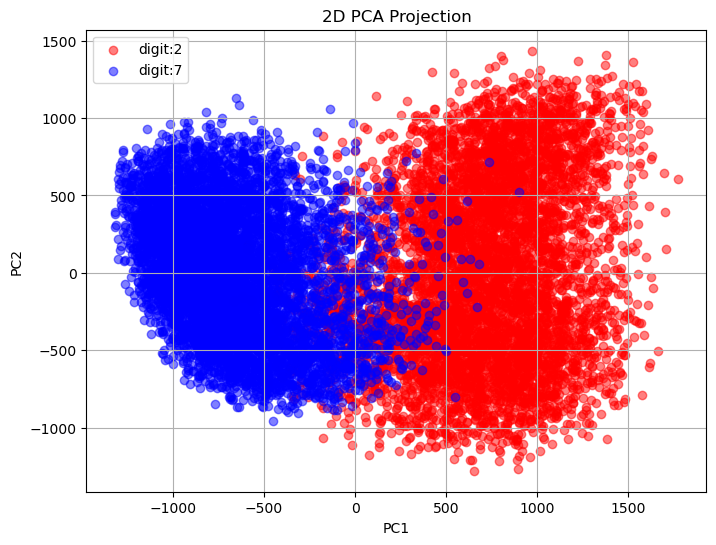

In [43]:
pca = PCA(n_components=2)
X_train27_pca = pca_k.fit_transform(X_subtrain27.T) 
mask2 = np.isin(y_subtrain27 , 2)
mask7 = np.isin(y_subtrain27 , 7)
plt.figure(figsize=(8, 6))
plt.scatter(X_train27_pca.T[0,mask2], 
            X_train27_pca.T[1,mask2], 
             c='r', label='digit:2', alpha=0.5)
plt.scatter(X_train27_pca.T[0,mask7], 
            X_train27_pca.T[1,mask7], 
             c='b', label='digit:7', alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.legend()
plt.grid()
plt.show()

In [44]:
pca_k = PCA(n_components=k_85)
X_subtrain27_pca = pca_k.fit_transform(X_subtrain27.T) 
X_subtest27_pca = pca_k.transform(X_subtest27.T)

ridge_clf = RidgeClassifier()
ridge_clf.fit(X_subtrain27_pca, y_subtrain27)

cv_scores = cross_val_score(ridge_clf, X_subtrain27_pca, y_subtrain27, cv=5)
print(f"The accuracy of cross-validation(2 and 7): {cv_scores.mean():.4f}")

y_pred27 = ridge_clf.predict(X_subtest27_pca)
test_accuracy = accuracy_score(y_subtest27, y_pred27)
print(f"The accuracy for testing(2 and 7): {test_accuracy:.4f}")

The accuracy of cross-validation(2 and 7): 0.9810
The accuracy for testing(2 and 7): 0.9728


In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import SGDClassifier

pca_k = PCA(n_components=k_85)
Xtraindata_pca = pca_k.fit_transform(Xtraindata.T) 
Xtestdata_pca = pca_k.transform(Xtestdata.T) 

ridge_clf = RidgeClassifier()
ridge_clf.fit(Xtraindata_pca, ytrainlabels)

cv_scores = cross_val_score(ridge_clf, Xtraindata_pca, ytrainlabels, cv=5)
print(f"The accuracy of cross-validation(Ridge): {cv_scores.mean():.4f}")

y_predR = ridge_clf.predict(Xtestdata_pca)
test_accuracy = accuracy_score(ytestlabels, y_predR)
print(f"The accuracy for testing(Ridge): {test_accuracy:.4f}")

knn_clf = KNeighborsClassifier().fit(Xtraindata_pca, ytrainlabels)
lda_clf = LinearDiscriminantAnalysis().fit(Xtraindata_pca, ytrainlabels)

cv_scores = cross_val_score(knn_clf, Xtraindata_pca, ytrainlabels, cv=5)
print(f"The accuracy of cross-validation(KNN): {cv_scores.mean():.4f}")

y_predK = knn_clf.predict(Xtestdata_pca)
test_accuracy = accuracy_score(ytestlabels, y_predK)
print(f"The accuracy for testing(KNN): {test_accuracy:.4f}")

cv_scores = cross_val_score(lda_clf, Xtraindata_pca, ytrainlabels, cv=5)
print(f"The accuracy of cross-validation(LDA): {cv_scores.mean():.4f}")

y_predL = lda_clf.predict(Xtestdata_pca)
test_accuracy = accuracy_score(ytestlabels, y_predL)
print(f"The accuracy for testing(LDA): {test_accuracy:.4f}")

svm_clf = SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3)
svm_clf.fit(Xtraindata_pca, ytrainlabels)

cv_scores = cross_val_score(svm_clf, Xtraindata_pca, ytrainlabels, cv=5)
print(f"The accuracy of cross-validation(SVM): {cv_scores.mean():.4f}")

y_predS = svm_clf.predict(Xtestdata_pca)
test_accuracy = accuracy_score(ytestlabels, y_predS)
print(f"The accuracy for testing(SVM): {test_accuracy:.4f}")

The accuracy of cross-validation(Ridge): 0.8440
The accuracy for testing(Ridge): 0.8562
The accuracy of cross-validation(KNN): 0.9747
The accuracy for testing(KNN): 0.9757
The accuracy of cross-validation(LDA): 0.8653
The accuracy for testing(LDA): 0.8758
The accuracy of cross-validation(SVM): 0.8715
The accuracy for testing(SVM): 0.8808
